In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download('https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: crunchygremlin
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification


100%|██████████| 2.12G/2.12G [00:26<00:00, 85.5MB/s]


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
import librosa
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import time
from skimage.transform import resize

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
data_df = pd.read_csv('/content/quran-recitations-for-audio-classification/files_paths.csv')
print(len(data_df['Class'].unique()))
data_df.head()

12


,FilePath,Class
0,./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav,Mohammed_Aluhaidan
1,./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav,Mohammed_Aluhaidan
2,./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav,Mohammed_Aluhaidan
3,./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav,Mohammed_Aluhaidan
4,./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav,Mohammed_Aluhaidan


In [ ]:
data_df["FilePath"] = "/content/quran-recitations-for-audio-classification/Dataset" + data_df["FilePath"].str[1:]
data_df.head()

,FilePath,Class
0,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
1,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
2,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
3,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
4,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan


(6687, 2)
Class
Saud_Alshuraim          696
Saad_Alghamdi           688
AbdulRahman_Alsudais    648
Yasser_Aldossary        576
Ali_Alhothaify          576
Bander_Balilah          576
Maher_Almuaiqly         576
Abdullah_Albuaijan      504
Mohammed_Ayoub          480
Nasser_Alqutami         456
AbdulBari_Althubaity    456
Mohammed_Aluhaidan      455
Name: count, dtype: int64



<function matplotlib.pyplot.show(close=None, block=None)>

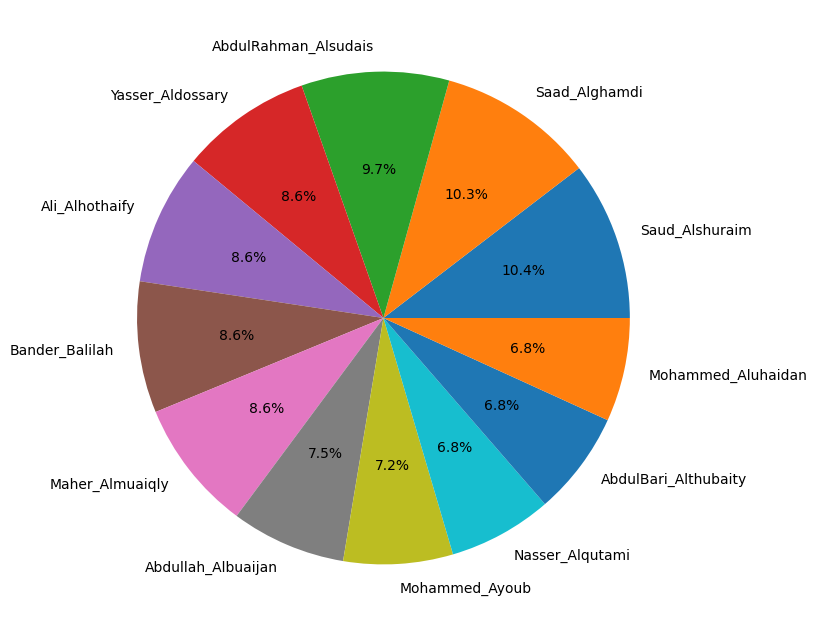

In [ ]:
print(data_df.shape)
print(data_df['Class'].value_counts())

print()

plt.figure(figsize = (8,8))
plt.pie(data_df['Class'].value_counts(), labels = data_df['Class'].value_counts().index, autopct = '%1.1f%%')
plt.title = ('Class Distribution')
plt.show

In [ ]:
label_encoder = LabelEncoder()
data_df['Class'] = label_encoder.fit_transform(data_df['Class'])
train = data_df.sample(frac = 0.7, random_state = 7)
test = data_df.drop(train.index)

val = test.sample(frac = 0.5, random_state = 7)
test = test.drop(val.index)

print(f'Train shape: {train.shape}')
print(f'Val shape: {val.shape}')
print(f'Test shape: {test.shape}')

Train shape: (4681, 2)
Val shape: (1003, 2)
Test shape: (1003, 2)


In [ ]:
class CustomAudioDataset(Dataset):
  def __init__(self, dataframe):
    self.dataframe = dataframe
    self.labels = torch.Tensor(list(dataframe["Class"])).type(torch.LongTensor).to(device)
    self.audios = [torch.Tensor(self.get_spectogram(path)).type(torch.FloatTensor) for path in dataframe['FilePath']]

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    image_path = self.dataframe.iloc[idx,0]
    label = torch.Tensor(self.labels[idx]).to(device)
    audio = self.audios[idx].unsqueeze(0).to(device)
    return audio, label

  def get_spectogram(self, file_path):
    sr = 22050 #SAMPLE RATE
    duration = 5

    img_height = 128
    img_width = 256

    signal, sr = librosa.load(file_path, sr = sr, duration = duration)
    #spectogram
    spec = librosa.feature.melspectrogram(y = signal, sr = sr, n_fft = 2048, hop_length = 512, n_mels = 128)

    #convert to decimal
    spec_db = librosa.power_to_db(spec, ref = np.max)

    spec_resized = librosa.util.fix_length(spec_db, size = (duration*sr)// 512+1)
    spec_resized = resize(spec_resized, (img_height, img_width), anti_aliasing = True)
    return spec_resized

In [ ]:
train_dataset = CustomAudioDataset(dataframe = train)
val_dataset = CustomAudioDataset(dataframe = val)
test_dataset = CustomAudioDataset(dataframe = test)

In [ ]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 25

In [ ]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1, 16, kernel_size = 3, padding = 1)
    self.conv2 = nn.Conv2d(16, 32, kernel_size = 3, padding = 1)
    self.conv3 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
    self.pooling = nn.MaxPool2d(2,2)
    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear((64*16*32), 4096)
    self.linear2 = nn.Linear(4096, 1024)
    self.linear3 = nn.Linear(1024, 512)
    self.output = nn.Linear(512, len(data_df['Class'].unique()))

    self.dropout = nn.Dropout(0.5)

  def forward(self,x):
    x = self.conv1(x)
    x = self.pooling(x)
    x = self.conv2(x)
    x = self.pooling(x)
    x = self.conv3(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = x.view(x.size(0), -1)

    x = self.flatten(x)
    x = self.linear1(x)
    x = self.dropout(x)

    x = self.linear2(x)
    x = self.dropout(x)

    x = self.linear3(x)
    x = self.dropout(x)

    x = self.output(x)
    return x

In [ ]:
model = Net().to(device)
print(model)

Net(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=32768, out_features=4096, bias=True)
  (linear2): Linear(in_features=4096, out_features=1024, bias=True)
  (linear3): Linear(in_features=1024, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=12, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
from torchsummary import summary
summary(model, (1, 128, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
         MaxPool2d-2          [-1, 16, 64, 128]               0
            Conv2d-3          [-1, 32, 64, 128]           4,640
         MaxPool2d-4           [-1, 32, 32, 64]               0
            Conv2d-5           [-1, 64, 32, 64]          18,496
         MaxPool2d-6           [-1, 64, 16, 32]               0
              ReLU-7           [-1, 64, 16, 32]               0
           Flatten-8                [-1, 32768]               0
            Linear-9                 [-1, 4096]     134,221,824
          Dropout-10                 [-1, 4096]               0
           Linear-11                 [-1, 1024]       4,195,328
          Dropout-12                 [-1, 1024]               0
           Linear-13                  [-1, 512]         524,800
          Dropout-14                  [

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [ ]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

import time
start_time = time.time()

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for input, labels in train_loader:
    outputs = model(input)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc

    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for input, labels in val_loader:
      outputs = model(input)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()
      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__() * 100 , 4))
  total_acc_validation_plot.append(round(total_acc_val/val_dataset.__len__() * 100 , 4))

  print(f'''Epoch: {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/1000, 4)}, Train Accuracy: {round(total_acc_train/train_dataset.__len__() * 100 , 4)},
          Validation Loss: {round(total_loss_val/1000, 4)}, Validation Accuracy: {round(total_acc_val/val_dataset.__len__() * 100 , 4)}''')
  print('='*70)

print('Training Time is: ', round((time.time() - start_time), 4), ' Seconds')


Epoch: 1/25, Train Loss: 0.0756, Train Accuracy: 92.0957,
          Validation Loss: 0.0153, Validation Accuracy: 92.323
Epoch: 2/25, Train Loss: 0.062, Train Accuracy: 94.2106,
          Validation Loss: 0.0148, Validation Accuracy: 93.32
Epoch: 3/25, Train Loss: 0.0595, Train Accuracy: 94.1252,
          Validation Loss: 0.0195, Validation Accuracy: 90.4287
Epoch: 4/25, Train Loss: 0.0484, Train Accuracy: 95.1079,
          Validation Loss: 0.0164, Validation Accuracy: 92.6221
Epoch: 5/25, Train Loss: 0.0374, Train Accuracy: 96.3042,
          Validation Loss: 0.011, Validation Accuracy: 95.4138
Epoch: 6/25, Train Loss: 0.047, Train Accuracy: 95.1079,
          Validation Loss: 0.0187, Validation Accuracy: 92.323
Epoch: 7/25, Train Loss: 0.0413, Train Accuracy: 96.0906,
          Validation Loss: 0.0168, Validation Accuracy: 94.2173
Epoch: 8/25, Train Loss: 0.0466, Train Accuracy: 96.0692,
          Validation Loss: 0.0177, Validation Accuracy: 93.4197
Epoch: 9/25, Train Loss: 0.0316

In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for input, labels in test_loader:
    prediction = model(input)

    acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
    total_acc_test += acc

  print(f'Total Accuracy: {round(total_acc_test/test_dataset.__len__() * 100, 4)}')

Total Accuracy: 94.6162


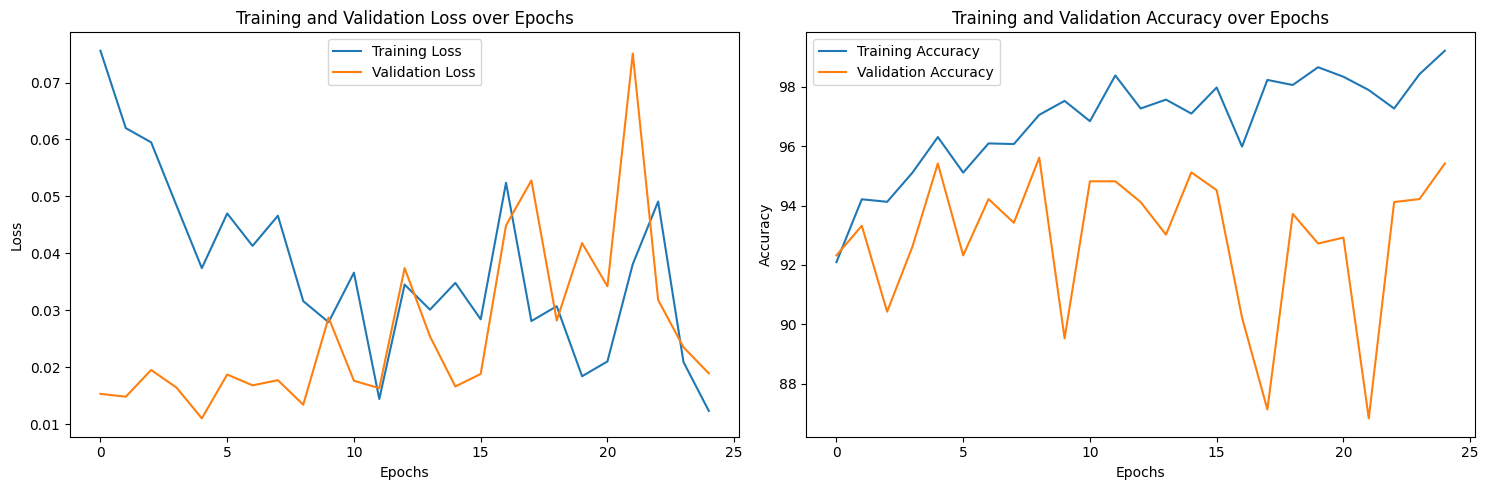

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()
plt.show()